#IMPORTS

In [1]:
import numpy as np
import pandas as pd


#READ CSV

In [2]:
df = pd.read_csv('/content/modified_placement_data.csv')

##TAKE A OVERVIEW OF CSV FILE USING HEAD FUNCTION

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123,1
1,1,5.9,106,0
2,2,5.3,121,0
3,3,7.4,132,1
4,4,5.8,142,0


In [4]:
df.shape

(100, 4)

#PREPROCESSING OF DATA

In [5]:
#REMOVING THE FIRST COLUMN
df = df.iloc[:,1:]

#ALL THE STEPS

Steps

 0. Preprocess + EDA + Feature Engineering
        (transformation | construction | selection | Extraction )
 1. Extract input and output cols
 2. Scale the values
 3. Train test split
 4. Train the model
 5. Evaluate the model/model selection
 6. Deploy the model

In [6]:
df.head()

,cgpa,iq,placement
0,6.8,123,1
1,5.9,106,0
2,5.3,121,0
3,7.4,132,1
4,5.8,142,0



 Steps

0. Preprocess + EDA + Feature Selection
 1. Extract input and output cols
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model

In [7]:
import matplotlib.pyplot as plt

#PLOTING A GRAPH BETWEEN CGPA AND IQ

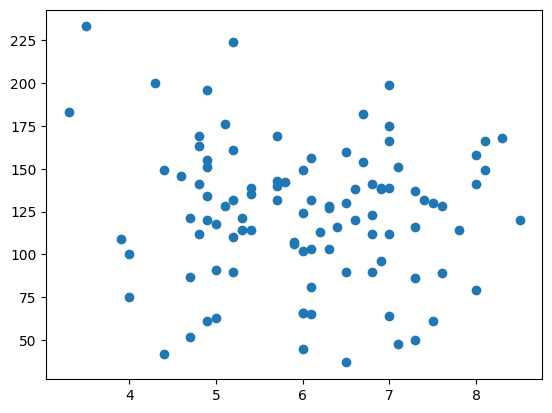

In [37]:
plt.scatter(df['cgpa'],df['iq'])

#SEPERATING IT WITH COLOR

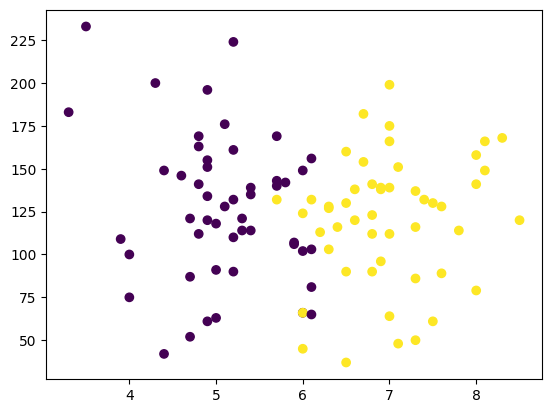

In [8]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

#SPLIT DEPENDENT AND INDEPENDENT COLUMNS

#SPLIT INPUT AND OUTPUT

In [9]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [10]:
X

,cgpa,iq
0,6.8,123
1,5.9,106
2,5.3,121
3,7.4,132
4,5.8,142
...,...,...
95,4.3,200
96,4.4,42
97,6.7,182
98,6.3,103


In [11]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [12]:
y.shape

(100,)

#SPLIT THE DATA INTO TEST AND TRAIN

In [13]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [14]:
X_train

,cgpa,iq
82,6.5,37
70,6.3,127
73,4.9,61
49,5.4,135
66,6.9,96
...,...,...
27,6.0,124
54,8.0,141
95,4.3,200
1,5.9,106


In [15]:
X_test

,cgpa,iq
4,5.8,142
93,6.8,112
68,4.0,75
57,6.5,130
46,5.3,114
0,6.8,123
72,7.3,116
48,6.6,138
33,6.0,149
52,7.0,175


In [16]:
y_test

,placement
4,0
93,1
68,0
57,1
46,0
0,1
72,1
48,1
33,0
52,1


In [17]:
y_test

,placement
4,0
93,1
68,0
57,1
46,0
0,1
72,1
48,1
33,0
52,1


#SCALE THE DATA


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
X_train = scaler.fit_transform(X_train)

In [21]:
X_train

array([[ 0.40703669, -2.10045401],
       [ 0.23782975,  0.09372673],
       [-0.94661882, -1.51533914],
       [-0.52360147,  0.28876502],
       [ 0.74545057, -0.66204663],
       [-0.26979106,  1.11767774],
       [ 0.40703669,  0.89825967],
       [ 1.16846792,  0.21562566],
       [ 1.67608873,  0.8495001 ],
       [ 0.40703669, -0.80832535],
       [ 1.7606922 ,  1.04453839],
       [-0.01598066, -1.39344021],
       [ 1.25307138,  0.16686609],
       [ 0.83005404,  0.38628416],
       [ 0.91465751,  0.6788416 ],
       [ 0.23782975, -0.49138813],
       [-0.94661882,  0.6788416 ],
       [ 0.32243322, -0.17445091],
       [-0.94661882,  0.26438523],
       [-1.03122229,  0.97139903],
       [-0.01598066, -1.90541572],
       [ 0.83005404, -1.44219978],
       [-0.26979106,  0.41066395],
       [-0.26979106,  0.48380331],
       [-0.01598066, -1.39344021],
       [-0.52360147,  0.38628416],
       [ 0.6608471 ,  0.43504374],
       [-0.01598066, -0.51576792],
       [-0.10058412,

In [22]:
X_test = scaler.transform(X_test)

In [23]:
X_test

array([[-0.18518759,  0.45942352],
       [ 0.6608471 , -0.27197006],
       [-1.70805004, -1.17402214],
       [ 0.40703669,  0.16686609],
       [-0.60820494, -0.22321048],
       [ 0.6608471 , -0.00379241],
       [ 1.08386445, -0.17445091],
       [ 0.49164016,  0.36190438],
       [-0.01598066,  0.63008202],
       [ 0.83005404,  1.26395646]])

#IMPORT LOGISTIC REGRESSION FROM LINEAR_MODEL


In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
clf = LogisticRegression()

# model training

In [26]:
clf.fit(X_train,y_train)

LogisticRegression()

In [27]:
clf

LogisticRegression()

# TESTING ON TEST DATA

In [28]:
y_pred = clf.predict(X_test)

In [29]:
y_pred

array([0, 1, 0, 1, 0, 1, 1, 1, 0, 1])

In [30]:
y_test

,placement
4,0
93,1
68,0
57,1
46,0
0,1
72,1
48,1
33,0
52,1


#CHECK ACCURACY

In [31]:

from sklearn.metrics import accuracy_score

In [32]:
accuracy_score(y_test,y_pred)

1.0

#PLOT DECISION REGRESSION


In [33]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

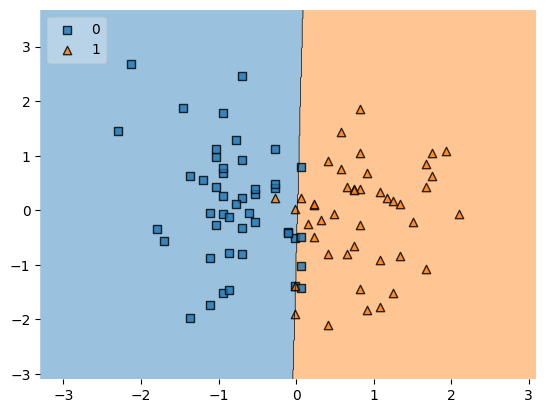

In [34]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [35]:
import pickle

In [36]:
pickle.dump(clf,open('model.pkl','wb'))